In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import SimpleITK as sitk
from tqdm import tqdm
import gc

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torch.nn.functional as F
from torch.cuda.amp import autocast, GradScaler # Для смешанной точности

# Настройки
CONFIG = {
    "lr": 1e-4,
    "batch_size": 16,
    "epochs": 100,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "image_size": 160,
    "seed": 42
}

print(f"Device used: {CONFIG['device']}")

Device used: cuda


In [2]:
class BraTSUnifiedDataset(Dataset):
    def __init__(self, root_dir, phase="train", split_ratio=0.8, image_size=240):
        self.phase = phase
        self.image_size = image_size
        self.patient_paths = []
        
        print(f"Сканирование директорий в {root_dir}...")
        
        # Рекурсивный обход всех папок
        for root, dirs, files in os.walk(root_dir):
            # Фильтруем только файлы снимков
            nii_files = [f for f in files if f.endswith('.nii') or f.endswith('.nii.gz')]
            
            if len(nii_files) >= 3:
                self.patient_paths.append(root)
        
        self.patient_paths = sorted(list(set(self.patient_paths)))
        
        if len(self.patient_paths) == 0:
            raise ValueError(f"Не найдено папок пациентов в {root_dir}. Проверьте путь.")
            
        print(f"--> Всего найдено пациентов: {len(self.patient_paths)}")

        # Разбиение на train/val
        np.random.seed(42)
        np.random.shuffle(self.patient_paths)
        split = int(len(self.patient_paths) * split_ratio)
        
        if phase == "train":
            self.patient_paths = self.patient_paths[:split]
        else:
            self.patient_paths = self.patient_paths[split:]

    def read_vol_and_extract_slice(self, path, slice_idx):
        if path is None:
            return np.zeros((self.image_size, self.image_size), dtype=np.float32)
            
        reader = sitk.ImageFileReader()
        reader.SetFileName(path)
        
        reader.ReadImageInformation()
        size = reader.GetSize() # (W, H, Depth)
        
        if slice_idx >= size[2]:
            slice_idx = size[2] // 2
            
        extract_index = [0, 0, int(slice_idx)]
        extract_size = [size[0], size[1], 0]        
        reader.SetExtractIndex(extract_index)
        reader.SetExtractSize(extract_size)
        
        img = reader.Execute()
        slice_img = sitk.GetArrayFromImage(img) # Сразу (H, W), без лишней оси Z
        
        return slice_img

    def normalize(self, slice_2d):
        mask = slice_2d > 0
        if mask.sum() > 0:
            mean = slice_2d[mask].mean()
            std = slice_2d[mask].std()
            slice_2d = (slice_2d - mean) / (std + 1e-8)
            slice_2d[~mask] = 0
        return slice_2d

    def _get_file_path(self, path, modality_tokens, exclude_tokens=None):
        files = glob.glob(os.path.join(path, "*.nii*"))
        
        for f in files:
            fname = os.path.basename(f).lower()
            if any(token in fname for token in modality_tokens):
                if exclude_tokens:
                    if any(ex in fname for ex in exclude_tokens):
                        continue
                return f
        return None

    def __len__(self):
        return len(self.patient_paths)

    def __getitem__(self, idx):
        path = self.patient_paths[idx]
        
        try:
            flair_p = self._get_file_path(path, ['flair'])
            t2_p = self._get_file_path(path, ['t2'])
            t1ce_p = self._get_file_path(path, ['t1ce', 't1c'])
            t1_p = self._get_file_path(path, ['t1'], exclude_tokens=['ce', 't1c'])
            mask_p = self._get_file_path(path, ['seg', 'ot', 'mask'])

            if not all([flair_p, t2_p, t1_p, t1ce_p, mask_p]):
                return self.__getitem__((idx + 1) % len(self))

            mask_reader = sitk.ImageFileReader()
            mask_reader.SetFileName(mask_p)
            mask_reader.ReadImageInformation()
            size = mask_reader.GetSize() # (W, H, Depth)
            depth = size[2]
            
            slice_idx = depth // 2
            
            if self.phase == "train":
                mask_img_full = mask_reader.Execute()
                vol_mask = sitk.GetArrayFromImage(mask_img_full)
                
                if vol_mask.max() > 0: 
                    z_indices = np.where(np.any(vol_mask > 0, axis=(1, 2)))[0]
                    if len(z_indices) > 0:
                        slice_idx = np.random.choice(z_indices)
                
                del vol_mask, mask_img_full
                
            flair_2d = self.read_vol_and_extract_slice(flair_p, slice_idx)
            t1_2d    = self.read_vol_and_extract_slice(t1_p, slice_idx)
            t1c_2d   = self.read_vol_and_extract_slice(t1ce_p, slice_idx)
            t2_2d    = self.read_vol_and_extract_slice(t2_p, slice_idx)
            
            mask_2d = self.read_vol_and_extract_slice(mask_p, slice_idx)
            
        except Exception as e:
            return self.__getitem__((idx + 1) % len(self))

        imgs = [flair_2d, t1_2d, t1c_2d, t2_2d]
        image = np.stack(imgs, axis=0) # (4, H, W)
        
        H, W = image.shape[1], image.shape[2]
        cx, cy = H // 2, W // 2
        sz = self.image_size // 2
        
        x1 = max(0, cx - sz)
        x2 = min(H, cx + sz)
        y1 = max(0, cy - sz)
        y2 = min(W, cy + sz)
        
        image = image[:, x1:x2, y1:y2]
        mask_2d = mask_2d[x1:x2, y1:y2]

        if image.shape[1] < self.image_size or image.shape[2] < self.image_size:
            pad_h = self.image_size - image.shape[1]
            pad_w = self.image_size - image.shape[2]
            image = np.pad(image, ((0,0), (0, pad_h), (0, pad_w)), mode='constant')
            mask_2d = np.pad(mask_2d, ((0, pad_h), (0, pad_w)), mode='constant')

        for i in range(image.shape[0]):
            image[i] = self.normalize(image[i])
        
        mask_2d[mask_2d > 0] = 1.0 
        
        return torch.from_numpy(image).float(), torch.from_numpy(mask_2d).float().unsqueeze(0)

In [3]:
# Инициализация
ROOT_DIR = "/kaggle/input/brain-tumor-segmentation-in-mri-brats-2015"
train_dataset = BraTSUnifiedDataset(ROOT_DIR, phase="train", image_size=CONFIG['image_size'])
val_dataset = BraTSUnifiedDataset(ROOT_DIR, phase="val", image_size=CONFIG['image_size'])

train_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'], shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=CONFIG['batch_size'], shuffle=False, num_workers=4, pin_memory=True)

Сканирование директорий в /kaggle/input/brain-tumor-segmentation-in-mri-brats-2015...
--> Всего найдено пациентов: 989
Сканирование директорий в /kaggle/input/brain-tumor-segmentation-in-mri-brats-2015...
--> Всего найдено пациентов: 989


In [4]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)


class UNet(nn.Module):
    def __init__(self, in_channels=4, out_channels=1):
        super().__init__()
        
        # --- ENCODER (Сжатие) ---
        
        # Блок 1 (64 канала)
        self.dconv_down1 = DoubleConv(in_channels, 64)
        
        # Блок 2 (128 каналов)
        self.dconv_down2 = DoubleConv(64, 128)
        
        # Блок 3 (256 каналов)
        self.dconv_down3 = DoubleConv(128, 256)
        
        # Блок 4 (512 каналов)
        self.dconv_down4 = DoubleConv(256, 512)

        # Блок 5 (Bottleneck / Горлышко - 1024 канала)
        self.dconv_bottleneck = DoubleConv(512, 1024)

        # Пулинг и апсемплинг
        self.maxpool = nn.MaxPool2d(2)
        self.upsample = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)        

        # --- DECODER (Расширение) ---
        
        # Up 1 (принимает 1024 снизу + 512 слева = 1536 входа -> сжимает до 512)
        self.dconv_up4 = DoubleConv(1024 + 512, 512)
        
        # Up 2 (принимает 512 снизу + 256 слева = 768 входа -> сжимает до 256)
        self.dconv_up3 = DoubleConv(512 + 256, 256)
        
        # Up 3 (принимает 256 снизу + 128 слева = 384 входа -> сжимает до 128)
        self.dconv_up2 = DoubleConv(256 + 128, 128)
        
        # Up 4 (принимает 128 снизу + 64 слева = 192 входа -> сжимает до 64)
        self.dconv_up1 = DoubleConv(128 + 64, 64)
        
        # Финальный слой
        self.conv_last = nn.Conv2d(64, out_channels, 1)

    def forward(self, x):
        # --- Спуск (Encoder) ---
        conv1 = self.dconv_down1(x) # [Batch, 64, H, W] -> Skip 1
        x = self.maxpool(conv1)

        conv2 = self.dconv_down2(x) # [Batch, 128, H/2, W/2] -> Skip 2
        x = self.maxpool(conv2)
        
        conv3 = self.dconv_down3(x) # [Batch, 256, H/4, W/4] -> Skip 3
        x = self.maxpool(conv3)   
        
        conv4 = self.dconv_down4(x) # [Batch, 512, H/8, W/8] -> Skip 4
        x = self.maxpool(conv4)
        
        # --- Дно (Bottleneck) ---
        x = self.dconv_bottleneck(x) # [Batch, 1024, H/16, W/16]
        
        # --- Подъем (Decoder) ---
        
        # Шаг 1 вверх
        x = self.upsample(x)        
        x = torch.cat([x, conv4], dim=1) # Конкатенация с 4-м скипом
        x = self.dconv_up4(x)
        
        # Шаг 2 вверх
        x = self.upsample(x)        
        x = torch.cat([x, conv3], dim=1) # Конкатенация с 3-м скипом
        x = self.dconv_up3(x)

        # Шаг 3 вверх
        x = self.upsample(x)        
        x = torch.cat([x, conv2], dim=1) # Конкатенация со 2-м скипом
        x = self.dconv_up2(x)   
        
        # Шаг 4 вверх
        x = self.upsample(x)
        x = torch.cat([x, conv1], dim=1) # Конкатенация с 1-м скипом
        x = self.dconv_up1(x)
        
        out = self.conv_last(x)
        
        return out

In [5]:
# --- БЛОК ТРАНСФОРМЕРА ---
class TransformerBottleneck(nn.Module):
    def __init__(self, in_channels, feature_map_size, num_heads=8, num_layers=4, hidden_dim=2048):
        super().__init__()
        
        # in_channels: например, 1024
        # feature_map_size: размер картинки на дне (например, 10x10)
        
        self.flatten_dim = feature_map_size * feature_map_size  # 10*10 = 100 токенов
        self.embed_dim = in_channels
        
        # Позиционное кодирование (чтобы сеть знала, где какой кусочек находится)
        self.pos_embedding = nn.Parameter(torch.randn(1, self.flatten_dim, self.embed_dim))
        
        # Сам трансформер (Encoder часть)
        encoder_layer = nn.TransformerEncoderLayer(d_model=self.embed_dim, nhead=num_heads, dim_feedforward=hidden_dim, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
    def forward(self, x):
        b, c, h, w = x.shape
        x = x.flatten(2).transpose(1, 2)
        x = x + self.pos_embedding
        x = self.transformer_encoder(x)
        x = x.transpose(1, 2).reshape(b, c, h, w)
        return x

class TransUNet(nn.Module):
    def __init__(self, in_channels=4, out_channels=1, img_size=160):
        super().__init__()
        
        # Рассчитываем размер на "дне". 
        # Мы делаем 4 пулинга (деление на 2): 160 -> 80 -> 40 -> 20 -> 10.
        self.bottleneck_size = img_size // 16 
        
        # --- ENCODER (CNN) ---
        self.dconv_down1 = DoubleConv(in_channels, 64)
        self.dconv_down2 = DoubleConv(64, 128)
        self.dconv_down3 = DoubleConv(128, 256)
        self.dconv_down4 = DoubleConv(256, 512) # Выход здесь пойдет в трансформер

        self.maxpool = nn.MaxPool2d(2)
        
        # Переходник перед трансформером (увеличим каналы до 1024)
        self.conv_embed = nn.Conv2d(512, 1024, kernel_size=1) 

        # --- BOTTLENECK (TRANSFORMER) ---
        # Вместо обычных сверток тут стоит Self-Attention
        self.transformer = TransformerBottleneck(
            in_channels=1024, 
            feature_map_size=self.bottleneck_size, # 10
            num_heads=8,      # Количество "голов" внимания
            num_layers=3      # Глубина трансформера
        )

        self.upsample = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)        

        # --- DECODER (CNN) ---
        # Возвращаемся к сверткам для восстановления разрешения
        self.dconv_up4 = DoubleConv(1024 + 512, 512)
        self.dconv_up3 = DoubleConv(512 + 256, 256)
        self.dconv_up2 = DoubleConv(256 + 128, 128)
        self.dconv_up1 = DoubleConv(128 + 64, 64)
        
        self.conv_last = nn.Conv2d(64, out_channels, 1)

    def forward(self, x):
        # --- Спуск (CNN) ---
        conv1 = self.dconv_down1(x) 
        x = self.maxpool(conv1)

        conv2 = self.dconv_down2(x) 
        x = self.maxpool(conv2)
        
        conv3 = self.dconv_down3(x) 
        x = self.maxpool(conv3)   
        
        conv4 = self.dconv_down4(x) 
        x = self.maxpool(conv4) # [Batch, 512, 10, 10]
        
        # --- Трансформер ---
        # Подготовка каналов (512 -> 1024)
        x = self.conv_embed(x) # [Batch, 1024, 10, 10]
        
        # Магия внимания
        x = self.transformer(x) # [Batch, 1024, 10, 10]
        
        # --- Подъем (CNN) ---
        x = self.upsample(x)        
        x = torch.cat([x, conv4], dim=1)
        x = self.dconv_up4(x)
        
        x = self.upsample(x)        
        x = torch.cat([x, conv3], dim=1)
        x = self.dconv_up3(x)

        x = self.upsample(x)        
        x = torch.cat([x, conv2], dim=1)
        x = self.dconv_up2(x)   
        
        x = self.upsample(x)
        x = torch.cat([x, conv1], dim=1)
        x = self.dconv_up1(x)
        
        out = self.conv_last(x)
        return out

In [6]:
# model = UNet(in_channels=4, out_channels=1).to(CONFIG['device'])
model = TransUNet(in_channels=4, out_channels=1, img_size=CONFIG['image_size']).to(CONFIG['device'])

In [7]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1.):
        super(DiceLoss, self).__init__()
        self.smooth = smooth

    def forward(self, inputs, targets):

        inputs = torch.sigmoid(inputs)
        
        inputs = inputs.view(-1)
        targets = targets.view(-1)
        
        intersection = (inputs * targets).sum()
        dice = (2. * intersection + self.smooth) / (inputs.sum() + targets.sum() + self.smooth)
        
        return 1 - dice


criterion = DiceLoss()
optimizer = optim.Adam(model.parameters(), lr=CONFIG['lr'])
scaler = torch.amp.GradScaler('cuda')
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

In [8]:
best_valid_loss = float('inf')
history = {'train_loss': [], 'val_loss': [], 'val_dice': []}

print("Starting training...")

for epoch in range(CONFIG['epochs']):
    # --- TRAIN ---
    model.train()
    train_loss = 0
    
    current_lr = optimizer.param_groups[0]['lr']
    
    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{CONFIG['epochs']} [LR={current_lr:.1e}]")
    
    for images, masks in loop:
        images = images.to(CONFIG['device'], non_blocking=True)
        masks = masks.to(CONFIG['device'], non_blocking=True)
        
        optimizer.zero_grad(set_to_none=True)
        
        with torch.amp.autocast('cuda', enabled=(CONFIG['device'] != 'cpu')):
            outputs = model(images)
            loss = criterion(outputs, masks)
        
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        train_loss += loss.item()
        loop.set_postfix(loss=loss.item())
        

    avg_train_loss = train_loss / len(train_loader)

    del images, masks, outputs, loss
    torch.cuda.empty_cache
    gc.collect()

    
    # --- VALIDATION ---
    model.eval()
    val_loss = 0
    val_dice = 0
    
    with torch.inference_mode():
        for images, masks in tqdm(val_loader, desc=f"Epoch {epoch+1}/{CONFIG['epochs']} [Val]"):
            images = images.to(CONFIG['device'], non_blocking=True)
            masks = masks.to(CONFIG['device'], non_blocking=True)
            
            with torch.amp.autocast('cuda', enabled=(CONFIG['device'] != 'cpu')):
                outputs = model(images)
                loss = criterion(outputs, masks)
            
            loss_value = loss.item()
            val_loss += loss_value
            
            val_dice += (1 - loss_value)

    del images, masks, outputs, loss
    torch.cuda.empty_cache()
    gc.collect()
    
    avg_val_loss = val_loss / len(val_loader)
    avg_val_dice = val_dice / len(val_loader)

    scheduler.step(avg_val_loss)
    
    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['val_dice'].append(avg_val_dice)
    
    print(f"Epoch [{epoch+1}/{CONFIG['epochs']}] Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Dice: {avg_val_dice:.4f}")
    
    if avg_val_loss < best_valid_loss:
        print(f"Validation loss decreased ({best_valid_loss:.4f} --> {avg_val_loss:.4f}). Saving model...")
        best_valid_loss = avg_val_loss
        torch.save(model.state_dict(), "best_model_trans_unet.pth")
    
    torch.cuda.empty_cache() 

print("Training finished!")

Starting training...


Epoch 1/100 [Val]: 100%|██████████| 13/13 [00:09<00:00,  1.35it/s]


Epoch [1/100] Loss: 0.7521 | Val Loss: 0.6882 | Val Dice: 0.3118
Validation loss decreased (inf --> 0.6882). Saving model...


Epoch 2/100 [Val]: 100%|██████████| 13/13 [00:06<00:00,  2.15it/s]


Epoch [2/100] Loss: 0.7075 | Val Loss: 0.6656 | Val Dice: 0.3344
Validation loss decreased (0.6882 --> 0.6656). Saving model...


...

Epoch [98/100] Loss: 0.0845 | Val Loss: 0.0877 | Val Dice: 0.9123


Epoch 99/100 [Val]: 100%|██████████| 13/13 [00:05<00:00,  2.28it/s]


Epoch [99/100] Loss: 0.0841 | Val Loss: 0.0879 | Val Dice: 0.9121


Epoch 100/100 [Val]: 100%|██████████| 13/13 [00:05<00:00,  2.36it/s]


Epoch [100/100] Loss: 0.0887 | Val Loss: 0.0820 | Val Dice: 0.9180
Validation loss decreased (0.0838 --> 0.0820). Saving model...
Training finished!


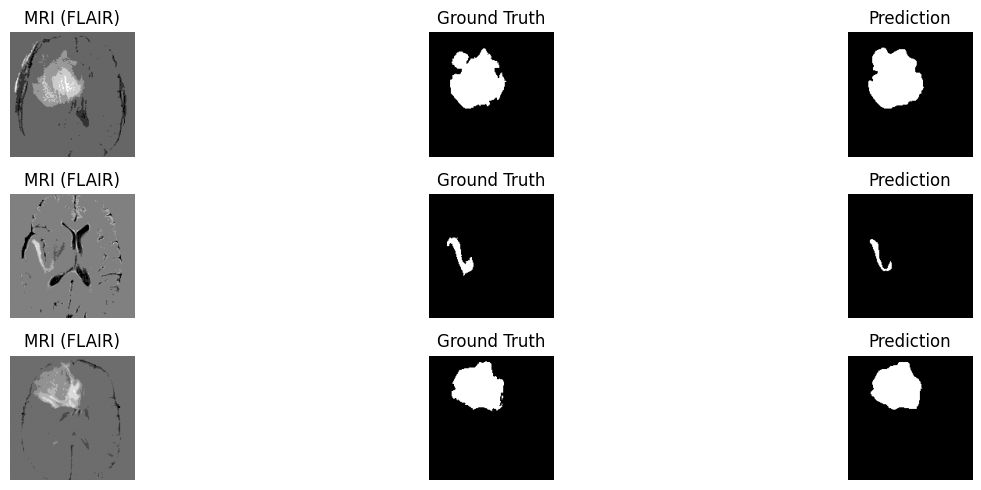

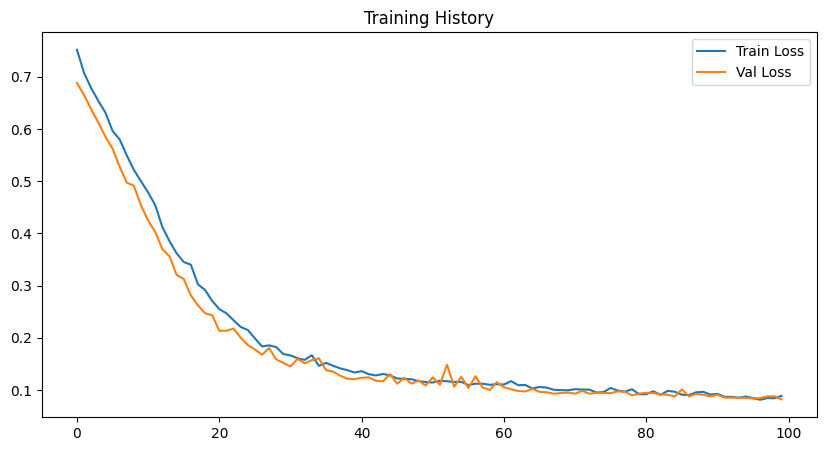

In [10]:
# Загрузка лучшей модели
model.load_state_dict(torch.load("best_model_trans_unet.pth"))
model.eval()

# Берем случайный батч из валидации
images, masks = next(iter(val_loader))
images = images.to(CONFIG['device'])

with torch.no_grad():
    preds = model(images)
    preds = torch.sigmoid(preds)
    preds = (preds > 0.5).float() # Порог уверенности

# Визуализация
plt.figure(figsize=(15, 5))
for i in range(3): # Показать 3 примера
    plt.subplot(3, 3, i*3+1)
    # Показываем FLAIR канал (индекс 0)
    plt.imshow(images[i][0].cpu(), cmap='gray')
    plt.title("MRI (FLAIR)")
    plt.axis('off')

    plt.subplot(3, 3, i*3+2)
    plt.imshow(masks[i][0].cpu(), cmap='gray')
    plt.title("Ground Truth")
    plt.axis('off')

    plt.subplot(3, 3, i*3+3)
    plt.imshow(preds[i][0].cpu(), cmap='gray')
    plt.title("Prediction")
    plt.axis('off')

plt.tight_layout()
plt.show()

# График обучения
plt.figure(figsize=(10, 5))
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Training History')
plt.legend()
plt.show()